In [1]:
import polars as pl
import time
import hvplot
import powerlaw
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Prep

In [32]:
df = pl.read_csv('dc_rests.csv',infer_schema_length=3000, ignore_errors=True)

In [34]:
df['LICENSE_START_DATE'][0]

'2021/01/01 05:00:00+00'

## Convert Dates, Filtwr Out Test Records

In [37]:
# Convert the three date columns to pl.Datetime if needed
df = df.with_columns([
    pl.col("LICENSE_START_DATE").str.slice(0,10).alias("LICENSE_START_DATE"),
    pl.col("LICENSE_END_DATE").str.slice(0,10).alias("LICENSE_END_DATE"),
    pl.col("LICENSE_ISSUE_DATE").str.slice(0,10).alias("LICENSE_ISSUE_DATE"),
])

In [39]:
# Assume your Polars DataFrame is named `df`

# Convert the three date columns to pl.Datetime if needed
df = df.with_columns([
    pl.col("LICENSE_START_DATE").str.to_date("%Y/%m/%d").alias("LICENSE_START_DATE"),
    pl.col("LICENSE_END_DATE").str.to_date("%Y/%m/%d").alias("LICENSE_END_DATE"),
    pl.col("LICENSE_ISSUE_DATE").str.to_date("%Y/%m/%d").alias("LICENSE_ISSUE_DATE"),
])

df = df.filter(pl.col('ENTITY_NAME') != "TEST RECORD DO NOT PROCESS")
df = df.filter(pl.col('ENTITY_NAME') != "test")

## Remove records with multiple rests at one biz 

In [42]:
df =df.with_columns(pl.count().over("SITE_ADDRESS","ENTITY_NAME").alias('count'))
df = df.filter(pl.col('count') <2)

C:\Users\lukep\AppData\Local\Temp\ipykernel_10768\2704930990.py:1: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  df =df.with_columns(pl.count().over("SITE_ADDRESS","ENTITY_NAME").alias('count'))


## Get time open and close status

In [45]:
# First melt the date columns
df_melted = df.melt(
    id_vars=["SITE_ADDRESS", "ENTITY_NAME", "LICENSESTATUS"],
    value_vars=["LICENSE_START_DATE", "LICENSE_END_DATE", "LICENSE_ISSUE_DATE"],
    variable_name="date_type",
    value_name="date"
)

C:\Users\lukep\AppData\Local\Temp\ipykernel_10768\1082955858.py:2: DeprecationWarning: `DataFrame.melt` is deprecated. Use `unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  df_melted = df.melt(


In [47]:
df_melted

SITE_ADDRESS,ENTITY_NAME,LICENSESTATUS,date_type,date
str,str,str,str,date
"""3423 14TH ST NW ""","""GEVANI INCORPORATED""","""Abandoned""","""LICENSE_START_DATE""",2013-03-01
"""505 9TH ST NW ""","""BRUEGGERS ENTERPRISES INC""","""Abandoned""","""LICENSE_START_DATE""",2017-05-01
"""3703 14TH ST NW ""","""LE CAFE DE PARIS LLC""","""Abandoned""","""LICENSE_START_DATE""",2013-06-01
"""520 FLORIDA AVE NW ""","""SHAWS TAVERN LLC""","""Abandoned""","""LICENSE_START_DATE""",2013-07-01
"""620 MILWAUKEE PL SE ""","""FRIENDSHIP PUBLIC CHARTER SCHO…","""Abandoned""","""LICENSE_START_DATE""",2011-08-01
…,…,…,…,…
"""2400 M ST NW ""","""STARBUCKS COFFEE""","""Active""","""LICENSE_ISSUE_DATE""",2024-03-22
"""4000 WISCONSIN AVE NW ""","""CAFE' OLE', L.L.C.""","""Abandoned""","""LICENSE_ISSUE_DATE""",2022-07-16
"""4731 WISCONSIN AVE NW ""","""LEFT CAFE & BAKERY INC""","""Abandoned""","""LICENSE_ISSUE_DATE""",2022-07-16


In [49]:
df_melted.sort(by='date',descending=True)

SITE_ADDRESS,ENTITY_NAME,LICENSESTATUS,date_type,date
str,str,str,str,date
"""7821 WENDYRIDGE LANDE ""","""COAST GUARD CAFETERIA""","""Expired""","""LICENSE_START_DATE""",null
"""3500 VAN NESS ST NW ""","""CAFE LAUTREC INC""","""Expired""","""LICENSE_START_DATE""",null
"""751 8TH ST SE ""","""YOUNG SOOK CHOI""","""Expired""","""LICENSE_START_DATE""",null
"""1939 14TH ST NW ""","""G & R CORPORATION INC""","""Expired""","""LICENSE_START_DATE""",null
"""116 KENNEDY ST NW ""","""KSB ERICAS INC""","""Expired""","""LICENSE_START_DATE""",null
…,…,…,…,…
"""600 13TH ST NW ""","""MCCORMICK & SCHMICK""","""Abandoned""","""LICENSE_START_DATE""",1999-04-27
"""2100 2ND ST SW ""","""I L CREATION THE MARKET""","""Abandoned""","""LICENSE_START_DATE""",1999-04-22
"""1201 K ST NW ""","""JMD FOODS, INC""","""Abandoned""","""LICENSE_START_DATE""",1999-04-21


In [51]:
rests = df_melted.group_by(["SITE_ADDRESS", "ENTITY_NAME"]).agg([
    pl.col("date").sort_by("date", descending=True).first().alias("latest_date"),
    pl.col("LICENSESTATUS").sort_by("date", descending=True).first().alias("latest_status"),
    pl.col("date").sort_by("date", descending=True).last().alias("earliest_date")
])
rests

SITE_ADDRESS,ENTITY_NAME,latest_date,latest_status,earliest_date
str,str,date,str,date
"""1400 MARION BARRY AVE SE ""","""QUINTANILLA FOODS, LLC.""",2026-03-31,"""Active""",2024-03-26
"""928 U ST NW ""","""KETCHA FIRE ENTERPRISES LLC""",2022-07-17,"""Abandoned""",2011-04-01
"""13431 MARBLE ROCK DR ""","""SHOLLS COLONIAL CAFETERIA""",2022-07-09,"""Abandoned""",1999-05-01
"""2100 2ND ST SW ""","""I L CREATION THE MARKET""",2022-07-05,"""Abandoned""",1999-04-22
"""2121 K ST NW ""","""MR. K INC""",2022-07-09,"""Abandoned""",2006-05-01
…,…,…,…,…
"""1709 NEW YORK AVE NW ""","""ARAMARK CORPORATION""",2022-07-10,"""Abandoned""",2009-09-01
"""555 13TH ST NW ""","""RARDIN LLC""",2024-02-29,"""Cancelled""",2022-03-01
"""2455 18TH ST NW ""","""CLICK-U-CHICKEN OF ADAMS""",2022-07-16,"""Abandoned""",2002-05-01


In [53]:
rests

SITE_ADDRESS,ENTITY_NAME,latest_date,latest_status,earliest_date
str,str,date,str,date
"""1400 MARION BARRY AVE SE ""","""QUINTANILLA FOODS, LLC.""",2026-03-31,"""Active""",2024-03-26
"""928 U ST NW ""","""KETCHA FIRE ENTERPRISES LLC""",2022-07-17,"""Abandoned""",2011-04-01
"""13431 MARBLE ROCK DR ""","""SHOLLS COLONIAL CAFETERIA""",2022-07-09,"""Abandoned""",1999-05-01
"""2100 2ND ST SW ""","""I L CREATION THE MARKET""",2022-07-05,"""Abandoned""",1999-04-22
"""2121 K ST NW ""","""MR. K INC""",2022-07-09,"""Abandoned""",2006-05-01
…,…,…,…,…
"""1709 NEW YORK AVE NW ""","""ARAMARK CORPORATION""",2022-07-10,"""Abandoned""",2009-09-01
"""555 13TH ST NW ""","""RARDIN LLC""",2024-02-29,"""Cancelled""",2022-03-01
"""2455 18TH ST NW ""","""CLICK-U-CHICKEN OF ADAMS""",2022-07-16,"""Abandoned""",2002-05-01


Revoked 
Abandoned
Closed
Expired
Lapsed
Caneclled

In [56]:
for i in df['LICENSESTATUS'].unique():
            print(i)

Active-4YR
Lapsed
Active
Cancelled
Expired
Suspended
Deficient
Pending
Revoked
Closed
Ready to Renew
Active4Yr
Abandoned
Transferred


In [58]:
# Filter to only abandoned licenses
rests = rests.with_columns(pl.when(pl.col("latest_status").is_in(["Abandoned",
                         "Closed", "Expired", "Lapsed", "Cancelled"]) 
                          ).then(1).otherwise(0).alias('closed')
                  )
rests = rests.with_columns((pl.col('latest_date') - pl.col('earliest_date')).dt.total_days().alias('time_open'))


In [60]:
rests = rests.drop_nulls()

In [62]:
rests['time_open'].hvplot.hist()

AttributeError: 'Series' object has no attribute 'hvplot'

In [548]:
x = rests.filter((pl.col('latest_date').dt.year() < 2020) &
             (pl.col('latest_date').dt.year() > 2011)).select('ENTITY_NAME','time_open','closed').drop_nulls()

In [66]:
x.columns

['ENTITY_NAME', 'time_open', 'closed']

In [164]:
x2 = rests.filter(pl.col('closed')==1,
                  pl.col('latest_date').dt.year() < 2020,
                  pl.col('latest_date').dt.year() > 2011
                  )


In [1]:
plt.figure(figsize=(12,8))

plt.hist(rests['time_open'], bins=2000)

import matplotlib.dates as mdates
plt.xlabel('Days Open')

plt.ylim(0,200)
plt.draw()

plt.savefig('days_open_hist.png')

NameError: name 'plt' is not defined

In [72]:
rests["time_open"]

time_open
i64
735
4125
8470
8475
5913
…
4695
730
7381


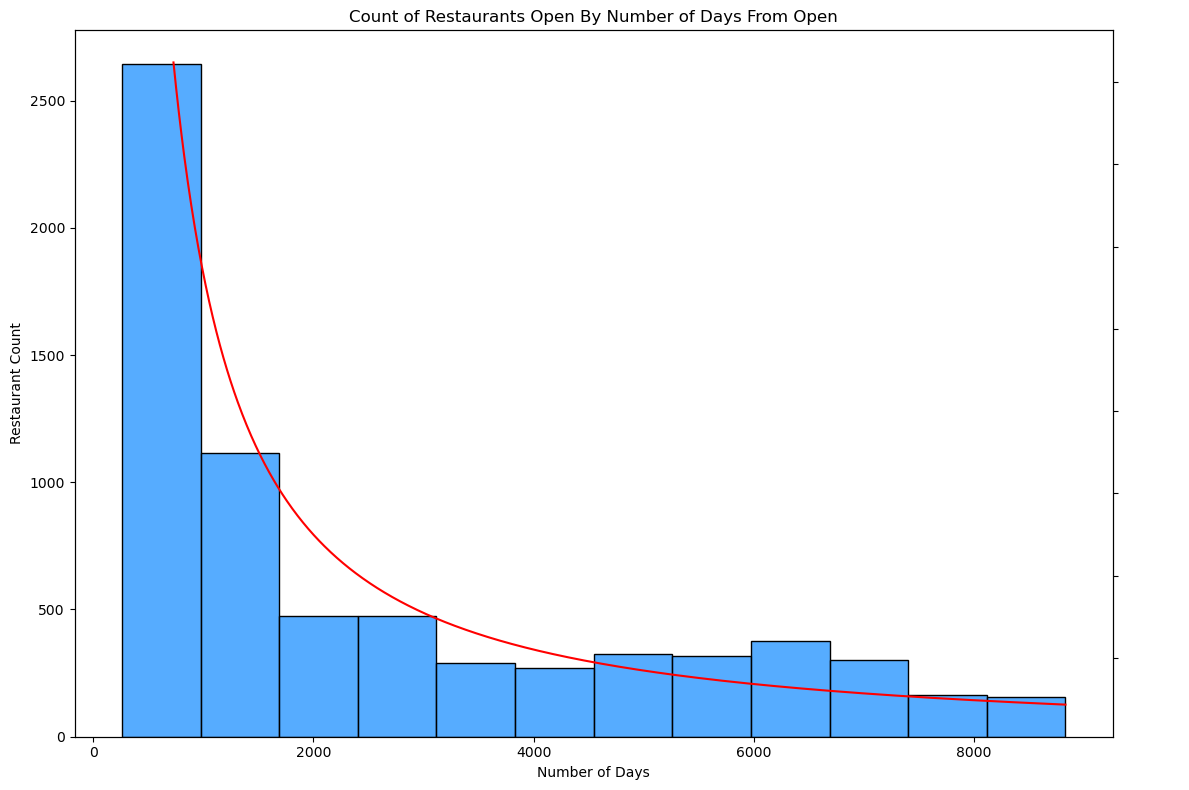

In [641]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setup
fig, ax1 = plt.subplots(figsize=(12, 8))

plt.title('Count of Restaurants Open By Number of Days From Open')

# Plot histogram on left y-axis
sns.histplot(rests["time_open"], bins=12, ax=ax1, color='dodgerblue')
ax1.set_xlabel('Number of Days')
ax1.set_ylabel('Restaurant Count', color='black')

ax1.tick_params(axis='y', labelcolor='black')

# Right axis for power-law
ax2 = ax1.twinx()

# Power-law function
alpha = 1.18246
xmin = 1
x_vals = np.linspace(729, rests2["time_open"].max(), 1000)
pdf_vals =  (1 / x_vals) ** (alpha )  # f(x) = 1.742 / x^2.742


# Scale line arbitrarily to fit histogram (optional tweak)
#scale = max(ax1.get_ylim()) / max(pdf_vals)
ax2.plot(x_vals, pdf_vals, color='red', linestyle='-', label=r'Power-law: $1.742 / x^{2.742}$')



ax2.tick_params(axis='y', labelcolor='white')

# Show
fig.tight_layout()


plt.draw()
plt.savefig('final_all_pareto_and_hist.png')

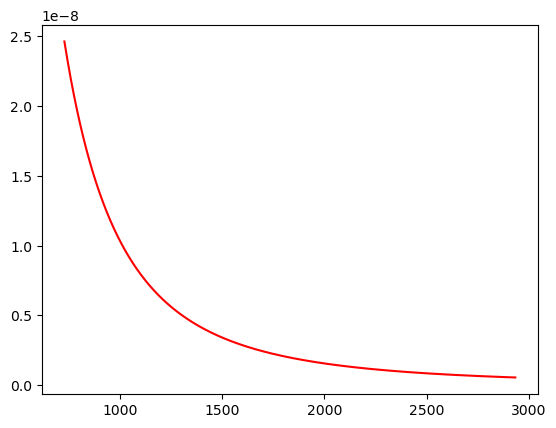

In [247]:
# Define power-law function
alpha = 1.742
xmin = 1  # Make sure your data doesn't include zeros
x_vals = np.linspace(729, x2["time_open"].max(), 1000)
pdf_vals = alpha / (x_vals ** (alpha + 1))  # PDF: alpha / x^{alpha+1}

# Plot power-law line
plt.plot(x_vals, pdf_vals, color='red', linestyle='-', label=r'Power-law fit: $\frac{1.742}{x^{2.742}}$')

#plt.savefig('rest_hist3.png')
#-----------------------------------------------#

In [180]:
x["time_open"].to_numpy().min()

545

<Axes: xlabel='time_open', ylabel='Density'>

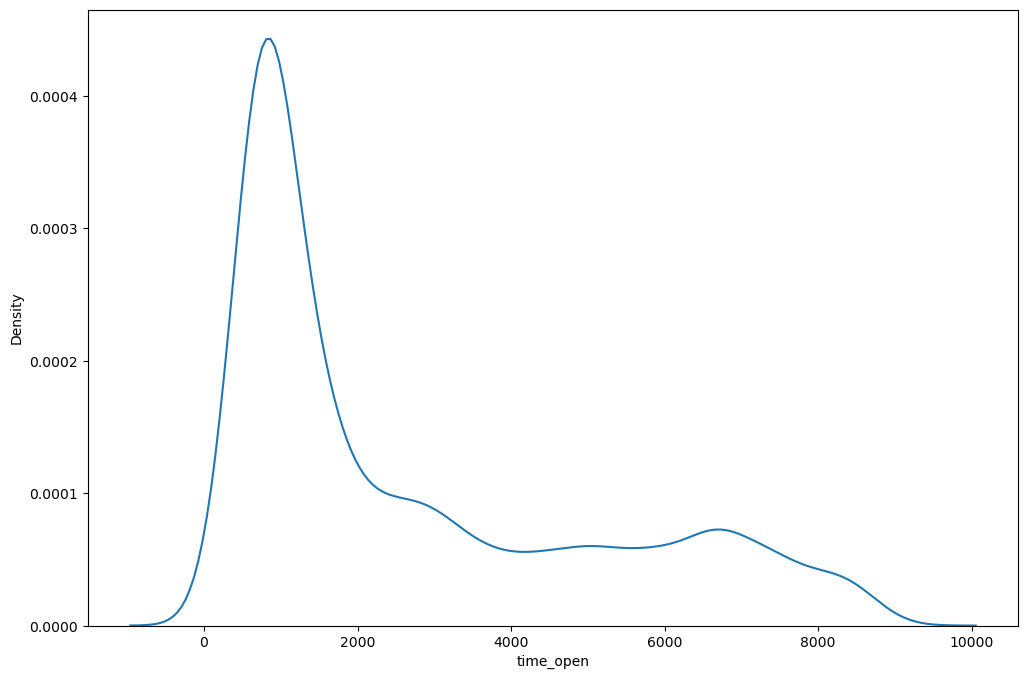

In [453]:
plt.figure(figsize=(12,8))

sns.kdeplot(x=rests["time_open"])


# Fit Powerlaw

In [38]:
az.summary(trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,0.353,0.005,0.343,0.362,0.0,0.0,2584.0,2495.0,1.0


In [462]:
#x = x.filter(pl.col('time_open') > 659)

In [140]:
rests2 = rests.filter(pl.col('time_open') >= 728)

In [152]:
lifetimes = np.array(rests3['time_open'].to_list())
lifetimes = lifetimes
# lifetimes = your array of time_open for closed businesses
fit = powerlaw.Fit(lifetimes, xmin = 728)

# Look at the alpha (exponent)
print(f"Estimated alpha: {fit.alpha}")
print(f"Estimated xmin: {fit.xmin}")


Estimated alpha: 1.8075313769339099
Estimated xmin: 758.0


In [154]:
print(f"KS statistic: {fit.D}")


KS statistic: 0.16174251033879783


In [156]:
print(f"Power law plausibility p-value: {fit.D}")

Power law plausibility p-value: 0.16174251033879783


In [158]:
R, p = fit.distribution_compare('power_law')
print(f'Log-likelihood ratio: {R}, p-value: {p}')

TypeError: Fit.distribution_compare() missing 1 required positional argument: 'dist2'

In [458]:
rests2

SITE_ADDRESS,ENTITY_NAME,latest_date,latest_status,earliest_date,closed,time_open
str,str,date,str,date,i32,i64
"""2436 18TH ST NW ""","""PV Admo LLC""",2023-11-30,"""Cancelled""",2021-12-01,1,729
"""900 19TH ST NW ""","""ELEPHANT & CASTLE PUB RESTAURA…",2022-07-17,"""Abandoned""",2009-03-01,1,4886
"""1275 1ST ST NE ""","""ROTI MEDITERRANEAN GRILL""",2025-01-31,"""Active""",2023-02-01,0,730
"""2400 WISCONSIN AVE NW ""","""DUMPLINGS AND BEYOND""",2022-07-10,"""Abandoned""",2016-02-01,1,2351
"""201 MASSACHUSETTS AVE NE ""","""MESFIN, LLC.""",2022-07-10,"""Abandoned""",2008-05-01,1,5183
…,…,…,…,…,…,…
"""600 NEW HAMPSHIRE AVE NW ""","""CUP'A CUP'A, INC.""",2022-07-05,"""Abandoned""",1999-07-19,1,8387
"""327 S ST NE ""","""Lost Generation Brewing Compan…",2026-09-30,"""Active""",2022-10-01,0,1460
"""601 INDEPENDENCE AVE SW ""","""MCDONALDS 3595""",2018-11-30,"""Cancelled""",2016-12-01,1,729


728.0


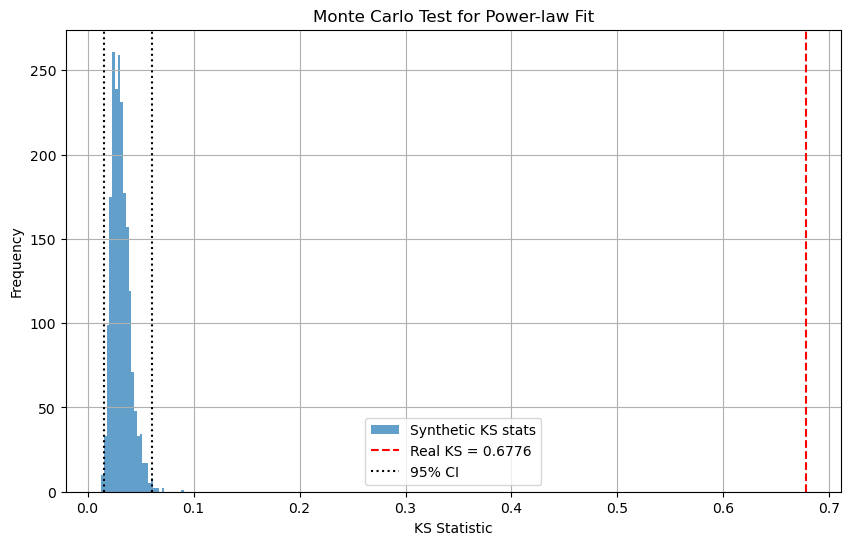

Real KS statistic: 0.6776
95% CI for KS under power-law: (0.0153, 0.0606)
P-value: 0.0000


<Figure size 640x480 with 0 Axes>

In [444]:
import numpy as np
import powerlaw
import matplotlib.pyplot as plt

# Step 1: Fit your actual data
data = x2['time_open']
fit = powerlaw.Fit(data, xmin=728, discrete=False)  # adjust xmin if needed

real_ks = fit.power_law.KS()
alpha = fit.power_law.alpha
xmin = fit.power_law.xmin
print(xmin)
# Step 2: Monte Carlo simulations
n_simulations = 2000
sim_ks_values = []

for _ in range(n_simulations):
    synthetic_data = (np.random.pareto(alpha - 1, size=len(data)) + 1) * xmin
    synthetic_fit = powerlaw.Fit(synthetic_data, xmin=xmin, discrete=False)
    ks = synthetic_fit.power_law.KS()
    sim_ks_values.append(ks)

sim_ks_values = np.array(sim_ks_values)

# Step 3: 95% confidence interval
lower_bound = np.percentile(sim_ks_values, 0.5)
upper_bound = np.percentile(sim_ks_values, 99.5)
p_value = np.mean(sim_ks_values >= real_ks)

# Step 4: Plot
plt.figure(figsize=(10, 6))
plt.hist(sim_ks_values, bins=30, alpha=0.7, label='Synthetic KS stats')
plt.axvline(real_ks, color='red', linestyle='--', label=f'Real KS = {real_ks:.4f}')
plt.axvline(lower_bound, color='black', linestyle=':', label='95% CI')
plt.axvline(upper_bound, color='black', linestyle=':')
plt.title('Monte Carlo Test for Power-law Fit')
plt.xlabel('KS Statistic')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

# Print results
print(f"Real KS statistic: {real_ks:.4f}")
print(f"95% CI for KS under power-law: ({lower_bound:.4f}, {upper_bound:.4f})")
print(f"P-value: {p_value:.4f}")

plt.savefig('monte_Carlo_test_p-l_fit.png')

#  Survival Curves

In [381]:
from lifelines import WeibullFitter, KaplanMeierFitter, NelsonAalenFitter


(720.0, 2000.0)

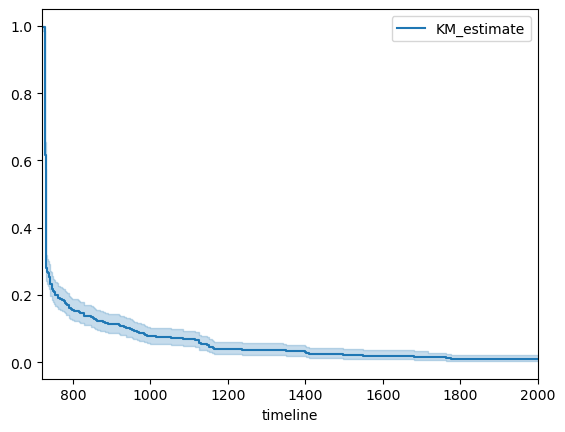

In [574]:
kmf = KaplanMeierFitter()
kmf.fit(x["time_open"].to_numpy(), x['closed'].to_numpy())
kmf.plot_survival_function()
plt.xlim(720,2000)


In [385]:
kmf

<lifelines.KaplanMeierFitter:"KM_estimate", fitted with 538 total observations, 31 right-censored observations>

(750.0, 2000.0)

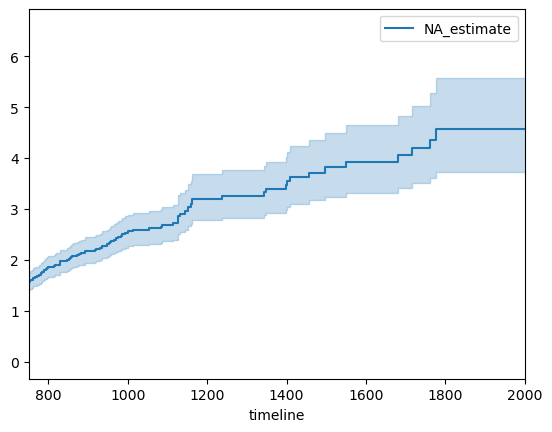

In [590]:
naf = NelsonAalenFitter()
naf.fit(x["time_open"].to_numpy(), x['closed'].to_numpy())
naf.plot_cumulative_hazard()
plt.xlim(750,2000)


In [ ]:
#surv = kmf.survival_function_
# Get cumulative hazard
cum_hazard = naf.cumulative_hazard_
cum_hazard.columns = ['H']

# Compute survival function: S(t) = exp(-H(t))
surv = np.exp(-cum_hazard['H'])
times = cum_hazard.index.values
S_t = surv.values




expectations = []

for i, t in enumerate(times):
    S_current = S_t[i]

    if S_current < 1e-6 or i == len(times) - 1:
        expectations.append(np.nan)
        continue

    # Remaining survival values and time intervals
    remaining_S = S_t[i:] / S_current

    dt = np.diff(times[i:])
    # If dt is empty, skip
    if len(dt) == 0:
        expectations.append(np.nan)
        continue

    # Pad with last interval to match lengths
    dt = np.append(dt, dt[-1])

    expected_remain = np.sum(remaining_S * dt)
    expectations.append(expected_remain)


In [528]:
import pandas as pd

residual_life = pd.DataFrame({
    "time": times,  # drop last time since we skip it
    "expected_days_remaining": expectations
}).dropna()


In [598]:
x['time_open'].mean()

793.4574074074075

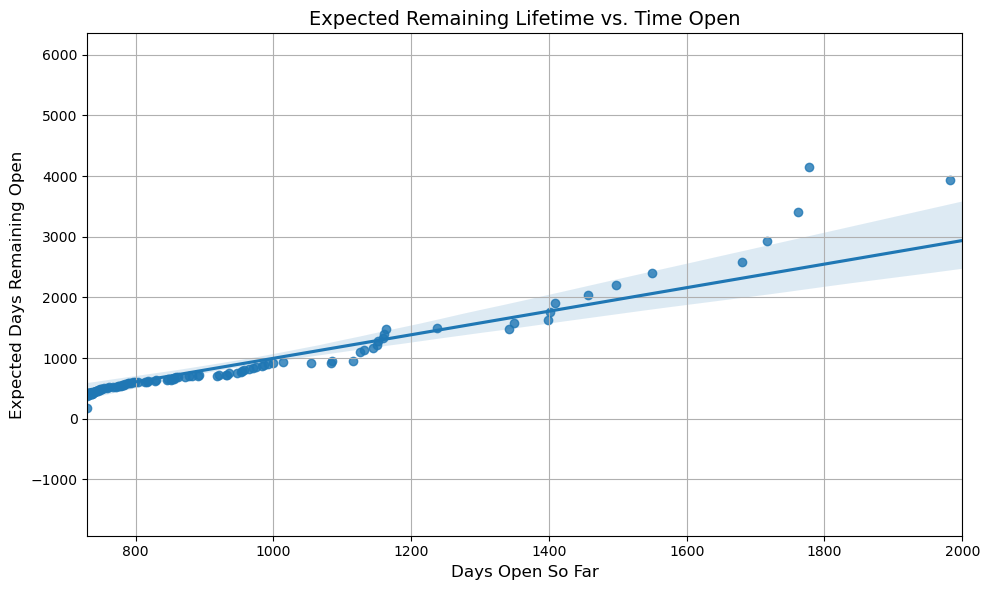

In [530]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.regplot(x=residual_life["time"], y=residual_life["expected_days_remaining"])
#sns.regplot(x=residual_life["time"], y=residual_life["time"] - 500)
plt.xlabel("Days Open So Far", fontsize=12)
plt.ylabel("Expected Days Remaining Open", fontsize=12)
plt.title("Expected Remaining Lifetime vs. Time Open", fontsize=14)
plt.grid(True)
plt.xlim(730, 2000)  # Adjust as needed
plt.tight_layout()

plt.draw()

plt.savefig('super_lindy_open.png')

In [532]:
import statsmodels.api as sm

X = sm.add_constant(residual_life["expected_days_remaining"])  # add intercept
model = sm.OLS(residual_life["expected_days_remaining"],residual_life["time"]).fit()
print(model.summary())

                                   OLS Regression Results                                   
Dep. Variable:     expected_days_remaining   R-squared (uncentered):                   0.860
Model:                                 OLS   Adj. R-squared (uncentered):              0.858
Method:                      Least Squares   F-statistic:                              607.6
Date:                     Mon, 05 May 2025   Prob (F-statistic):                    4.84e-44
Time:                             22:57:21   Log-Likelihood:                         -760.71
No. Observations:                      100   AIC:                                      1523.
Df Residuals:                           99   BIC:                                      1526.
Df Model:                                1                                                  
Covariance Type:                 nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025    

# Test Fitted Powerlaw

In [636]:
rests.sort(by='time_open').write_csv('longest_open.csv')

In [606]:
x.filter(pl.col('time_open') ==x['time_open'].max())

ENTITY_NAME,time_open,closed
str,i64,i32
"""J STREET ENTERPRISES LP""",5396,0


In [202]:
# Determine max time_open and create steps of 10
max_time = x2["time_open"].max()
steps = list(range(0, max_time + 1, 10))

# Add row index to help track original rows
#x2 = x2.with_row_count("row_id")

# Create a DataFrame with one row per (row_id, step)
long_df = pl.concat([
    x2.select([
        pl.col("row_id"),
        pl.col("time_open"),
        pl.lit(int(step)).alias("step"),
        (pl.col("time_open") - step - 729).alias("time_open_minus_step")
    ])
    for step in steps
])

print(long_df)

shape: (149_646, 4)
┌────────┬───────────┬──────┬──────────────────────┐
│ row_id ┆ time_open ┆ step ┆ time_open_minus_step │
│ ---    ┆ ---       ┆ ---  ┆ ---                  │
│ u32    ┆ i64       ┆ i32  ┆ i64                  │
╞════════╪═══════════╪══════╪══════════════════════╡
│ 0      ┆ 729       ┆ 0    ┆ 0                    │
│ 1      ┆ 730       ┆ 0    ┆ 1                    │
│ 2      ┆ 730       ┆ 0    ┆ 1                    │
│ 3      ┆ 729       ┆ 0    ┆ 0                    │
│ 4      ┆ 729       ┆ 0    ┆ 0                    │
│ …      ┆ …         ┆ …    ┆ …                    │
│ 504    ┆ 730       ┆ 2930 ┆ -2929                │
│ 505    ┆ 729       ┆ 2930 ┆ -2930                │
│ 506    ┆ 730       ┆ 2930 ┆ -2929                │
│ 507    ┆ 729       ┆ 2930 ┆ -2930                │
│ 508    ┆ 730       ┆ 2930 ┆ -2929                │
└────────┴───────────┴──────┴──────────────────────┘


In [204]:
long_df = long_df.filter(pl.col('time_open_minus_step') >=0)

In [248]:
viz = long_df.group_by('step').agg(pl.col('time_open_minus_step').mean(), pl.col('time_open_minus_step').count().alias('n'))

In [263]:
viz.select('step', 'time_open_minus_step')

step,time_open_minus_step
i32,f64
0,51.885602
10,224.567568
20,254.468085
30,264.712644
40,274.074074
…,…
2160,44.0
2170,34.0
2180,24.0


(-10.0, 1010.0)

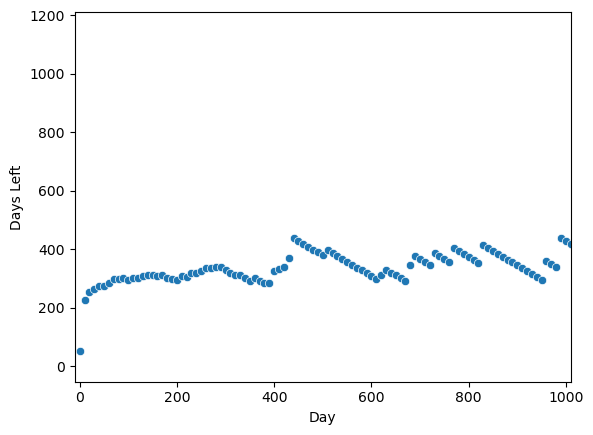

In [265]:
sns.scatterplot(x=viz['step'],y=viz['time_open_minus_step'])
plt.ylabel('Days Left')
plt.xlabel('Day')
plt.xlim(-10,1010)

<Axes: xlabel='time_open', ylabel='time_open_minus_step'>

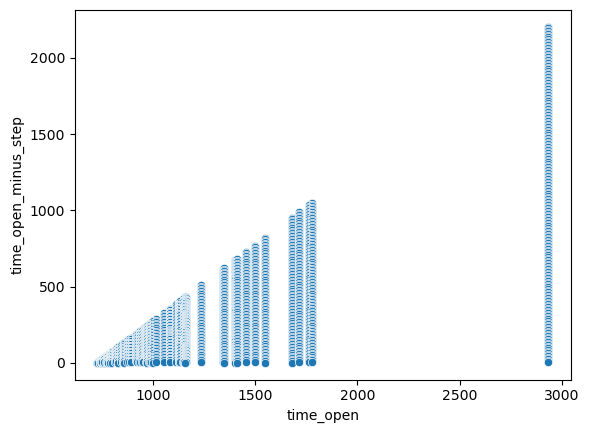

In [258]:
sns.scatterplot(x=long_df['time_open'],y=long_df['time_open_minus_step'])

In [261]:
viz.filter(pl.col('n')>5)

step,time_open_minus_step,n
i32,f64,u32
0,51.885602,507
10,224.567568,111
20,254.468085,94
30,264.712644,87
40,274.074074,81
…,…,…
780,393.833333,6
790,383.833333,6
800,373.833333,6


In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=rest